# Báo cáo Phần 2 - Cấu trúc doanh thu: Tiền thật sự đi đâu?
**Datathon 2026 · The Gridbreakers · VinTelligence**

## Luận điểm trung tâm

> Khuyến mãi đang bơm phồng doanh thu ngắn hạn nhưng làm xấu chất lượng biên lợi nhuận và chất lượng khách hàng. Sau khi tính đúng hoàn tiền và phí vận chuyển, toàn bộ 50 mẫu khuyến mãi lịch sử đều có đóng góp lợi nhuận gộp âm.

## Chuỗi nhân quả

```text
Khuyến mãi chạy
  -> rò rỉ biên lợi nhuận qua chiết khấu, hoàn tiền, phí vận chuyển  [Act 1]
  -> nhóm khách hàng có mua lại và lợi nhuận/khách thấp hơn          [Act 2]
  -> quyết định cắt vẫn dương dưới các kịch bản nhu cầu quay lại     [Act 3]
  -> khuyến mãi chồng lấn với tồn kho sẵn sàng yếu                   [Act 4]
  -> kê đơn hành động: cắt toàn bộ mẫu khuyến mãi lịch sử            [Act 5]
```

| Act | Câu hỏi trung tâm | Số liệu chính |
|-----|-------------------|------------|
| 1 | Doanh thu còn lại bao nhiêu sau rò rỉ? | Biên lợi nhuận 17.6% -> 5.4% |
| 2 | Khuyến mãi có phải nguồn rò rỉ chính? | 100.0% chương trình có đóng góp lợi nhuận gộp âm |
| 3 | Cắt khuyến mãi có bền dưới các kịch bản khác nhau không? | Đóng góp lợi nhuận gộp +84.3% đến +123.6% |
| 4 | Có thiệt hại vận hành ẩn không? | 426 điểm chồng lấn, tỷ lệ SKU thiếu hàng 67.5% |
| 5 | Nên làm gì? | CUT 50, KEEP 0, RESCHEDULE 0 |


In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent
CHARTS = ROOT / "outputs" / "charts"
TABLES = ROOT / "outputs" / "tables"


# Act 1 - Bề mặt vs. thực tế

**Câu hỏi trung tâm:** Doanh thu tăng, nhưng bao nhiêu phần doanh thu thật sự còn lại sau chiết khấu, hoàn tiền, phí vận chuyển và giá vốn?

Phân tích bắt đầu từ cấu trúc doanh thu để tách phần bị bào mòn khỏi phần lợi nhuận còn giữ lại.


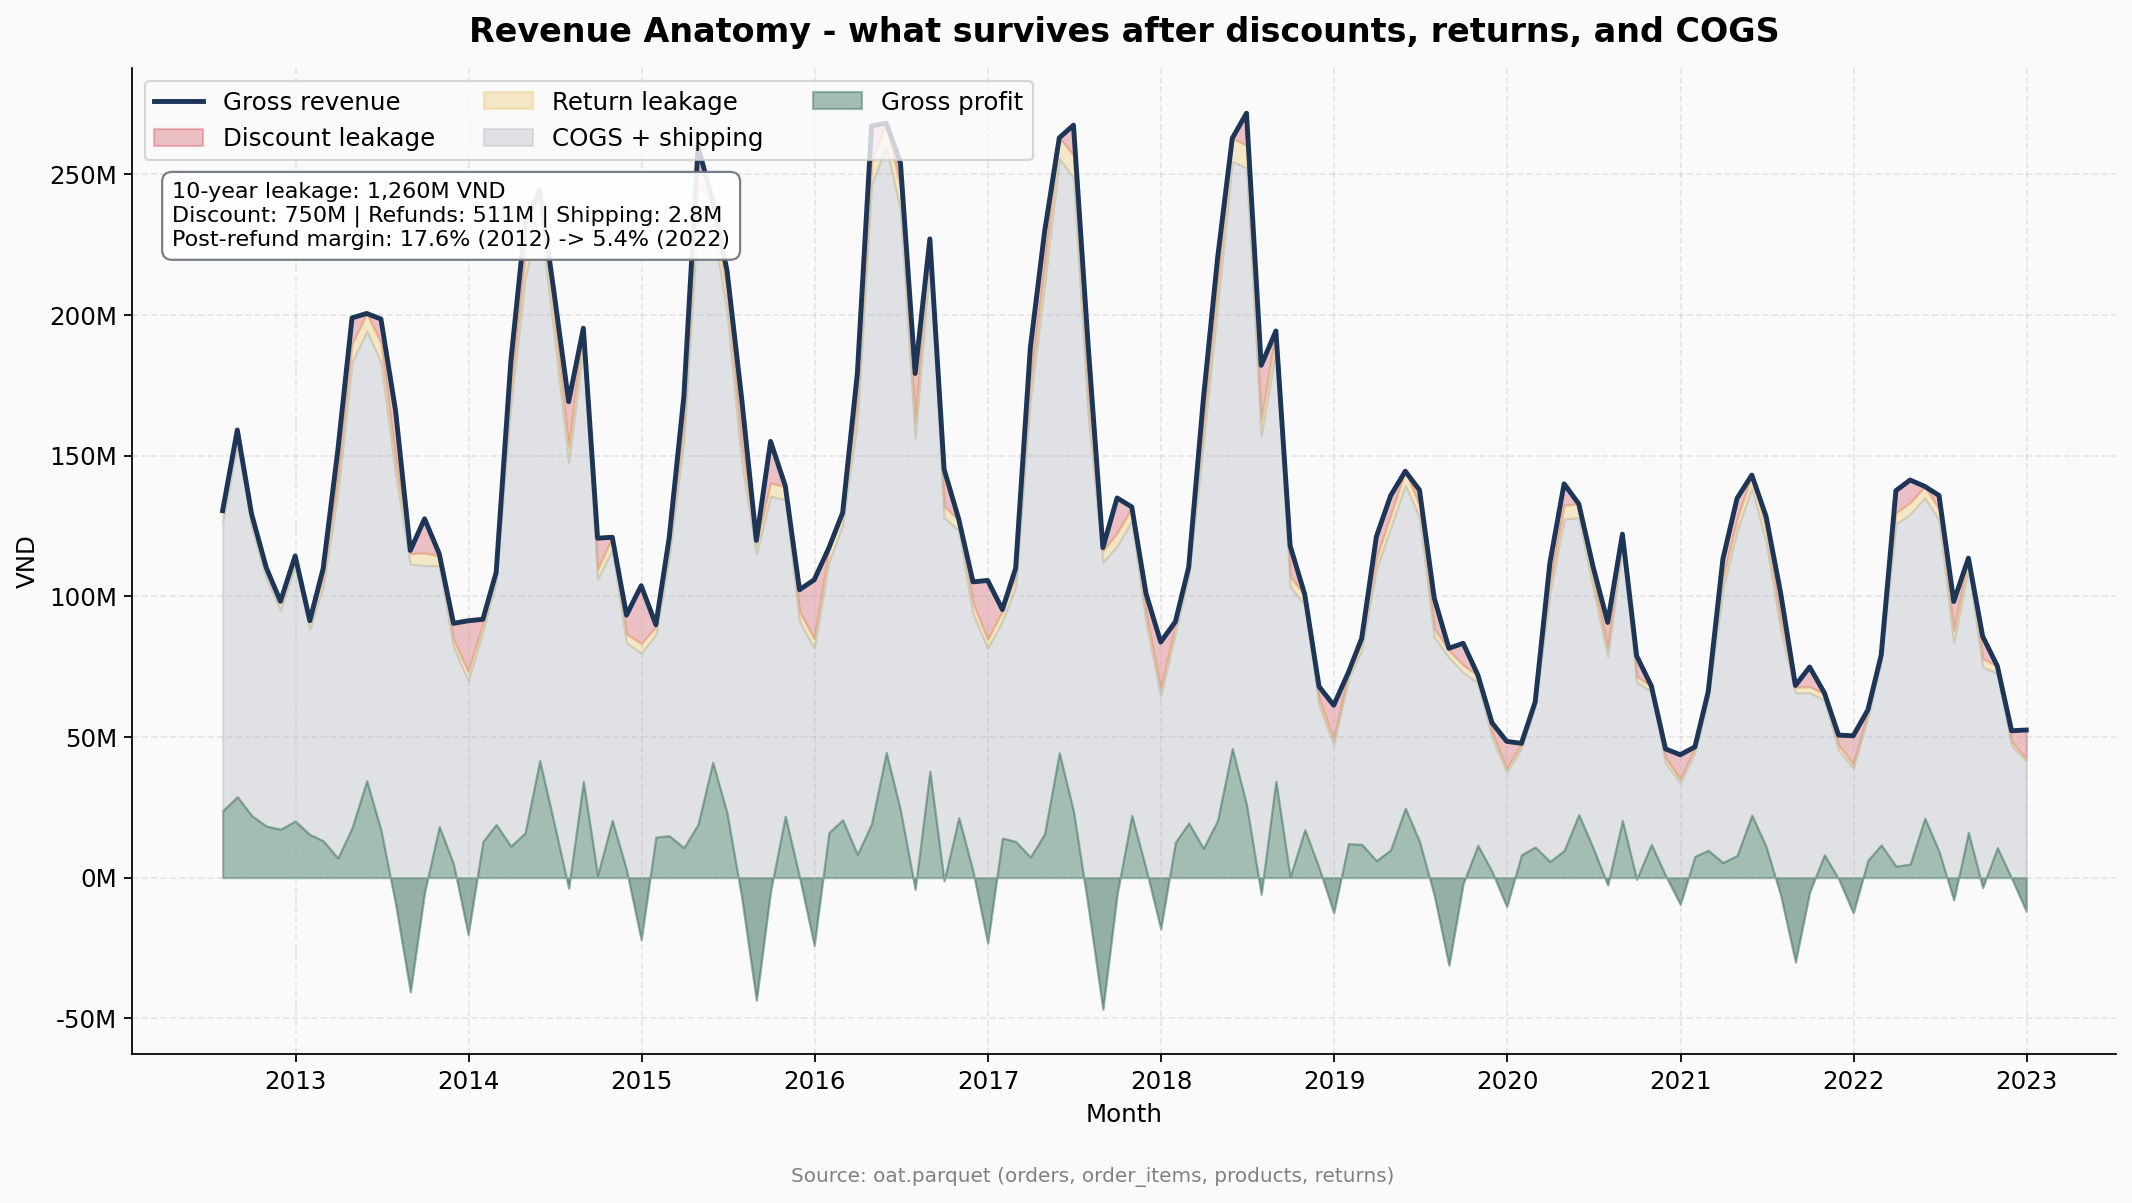

In [3]:
display(Image(str(CHARTS / "chart1_revenue_anatomy.png"), width=950))


In [4]:
category = pd.read_csv(TABLES / "category_double_loss_table.csv")
category_display = category.rename(columns={
    "category": "nganh_hang",
    "discount_rate": "ty_le_chiet_khau",
    "return_rate": "ty_le_tra_hang",
    "gross_revenue": "doanh_thu_gop",
    "rows": "so_dong",
    "quadrant": "nhom",
})
display(category_display)


,nganh_hang,ty_le_chiet_khau,ty_le_tra_hang,doanh_thu_gop,so_dong,nhom
0,Casual,0.049890,0.053937,4.606484e+08,23991,Mixed
1,GenZ,0.049249,0.057214,3.435991e+08,37159,Mixed
2,Outdoor,0.067613,0.056618,2.494883e+09,259986,Double loss
3,Streetwear,0.048063,0.055393,1.313135e+10,393533,Healthy


## Phân tích

Trong 10 năm, doanh nghiệp mất **749,607,320 VND** qua chiết khấu và **510,598,507 VND** qua hoàn tiền. Phí vận chuyển được phân bổ thêm **2,809,310 VND** vào từng dòng đơn hàng. Riêng chiết khấu và hoàn tiền đã tương đương **7.7% doanh thu gộp**, trước khi xét giá vốn.

Điểm quan trọng là biên lợi nhuận sau hoàn tiền và phí vận chuyển giảm từ **17.6% năm 2012** xuống **5.4% năm 2022**. Nghĩa là doanh nghiệp vẫn có thể tạo doanh thu, nhưng phần lợi nhuận giữ lại trên mỗi đồng doanh thu thuần ngày càng mỏng.

Biểu đồ phân nhóm ngành hàng chỉ có 4 điểm dữ liệu, nên nên dùng như bản đồ ưu tiên điều tra thay vì bằng chứng tuyệt đối. **Outdoor** là nhóm tương đối rủi ro hơn vì tỷ lệ chiết khấu và tỷ lệ trả hàng đều cao hơn trung vị. **Streetwear** có quy mô doanh thu lớn, nên dù tỷ lệ không xấu nhất, tác động tới lãi lỗ vẫn đáng chú ý.

**Kết luận Act 1:** Chất lượng doanh thu đang xấu đi. 
### Khuyến mãi có phải cơ chế chính làm xói mòn biên lợi nhuận hay không ?


# Act 2 - Ai đang làm rò rỉ biên lợi nhuận?

**Câu hỏi trung tâm:** Khuyến mãi có thật sự kéo về khách hàng tốt, hay chỉ tạo sản lượng rẻ với hiệu quả kinh tế kém?

Trọng tâm là kiểm tra hiệu quả từng chương trình khuyến mãi và chất lượng nhóm khách hàng đi kèm. Hành vi trả hàng là kiểm định phụ; bằng chứng chính nằm ở tỷ lệ mua lại và lợi nhuận gộp trên mỗi khách hàng.


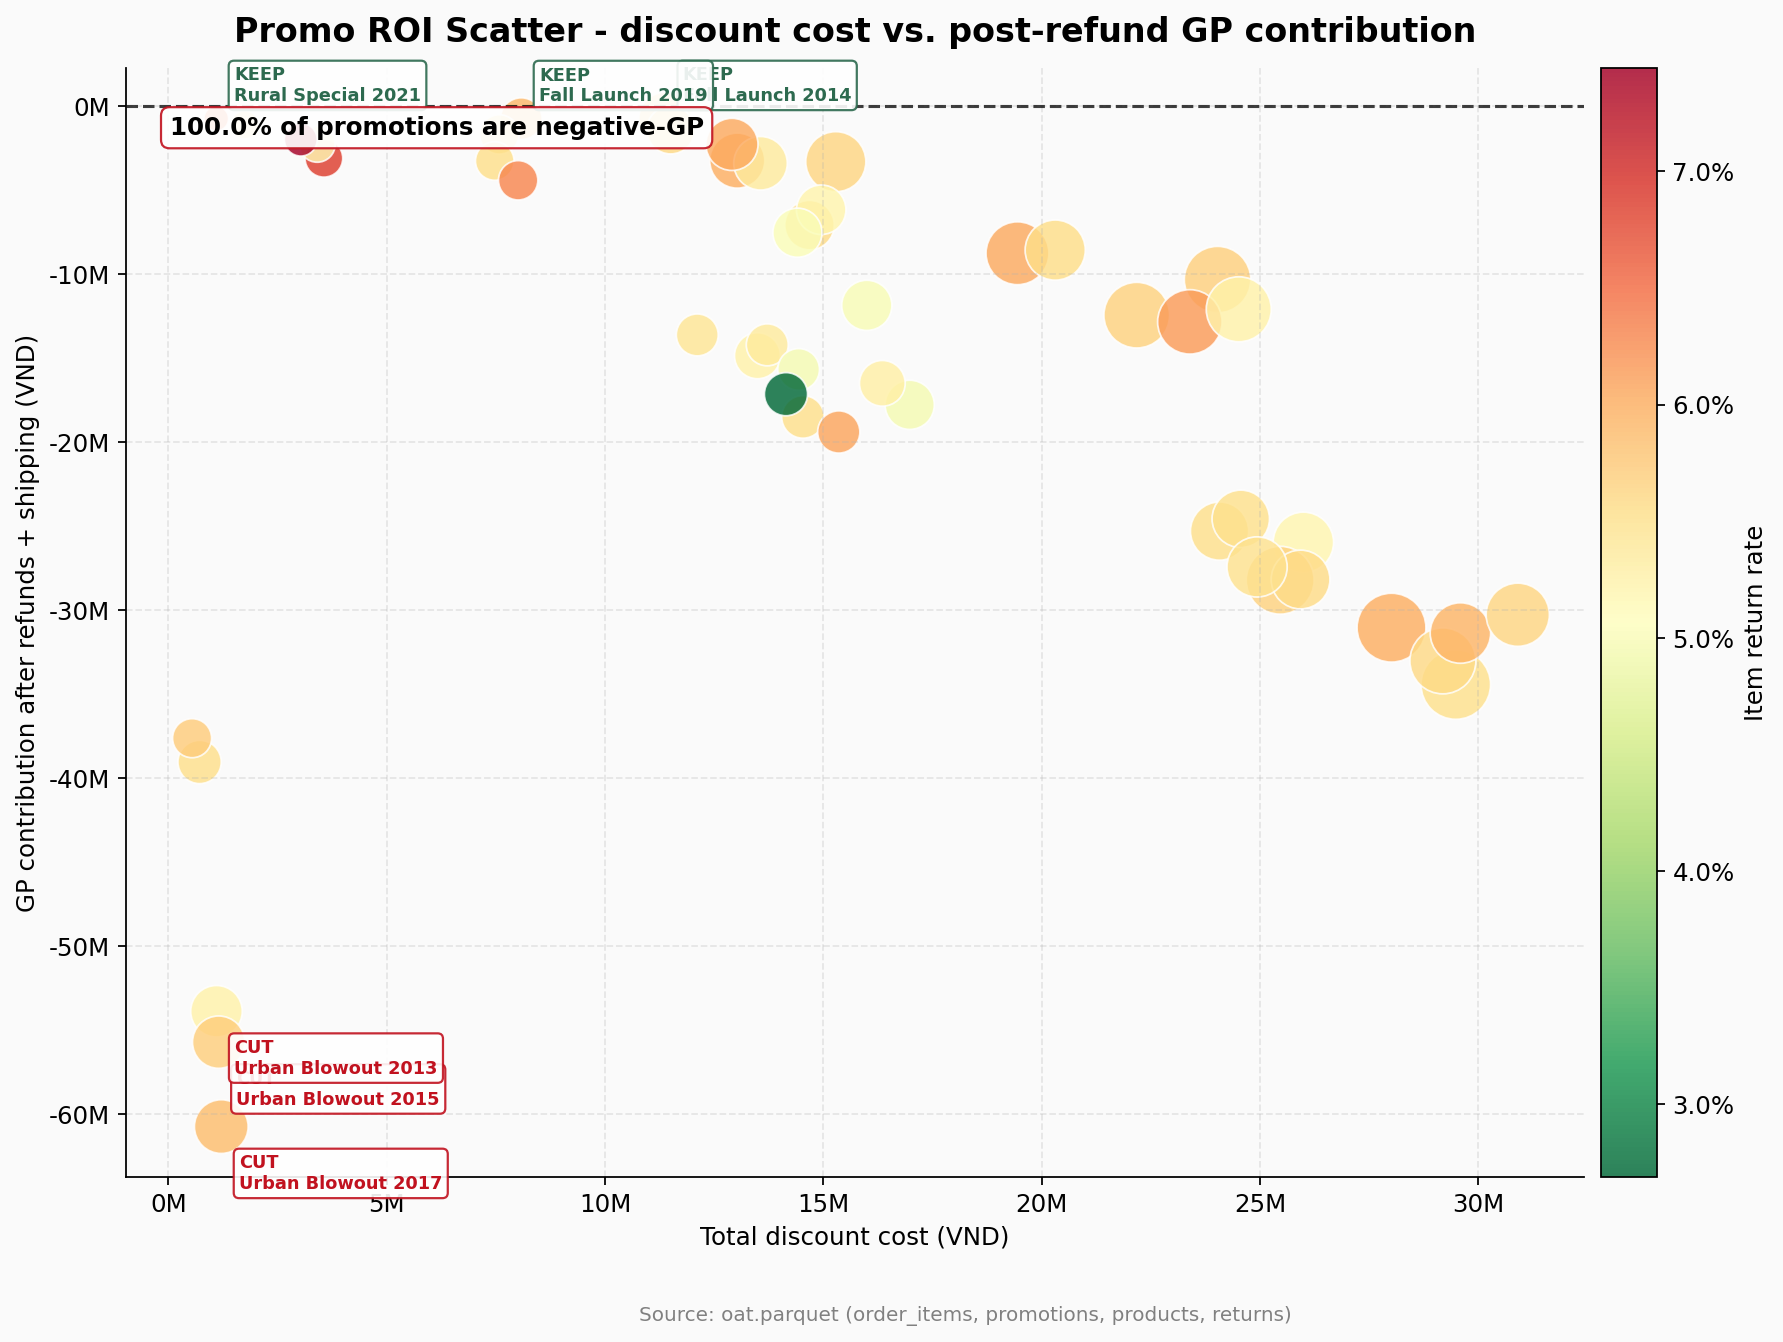

In [8]:
display(Image(str(CHARTS / "chart3_promo_roi_scatter.png"), width=950))


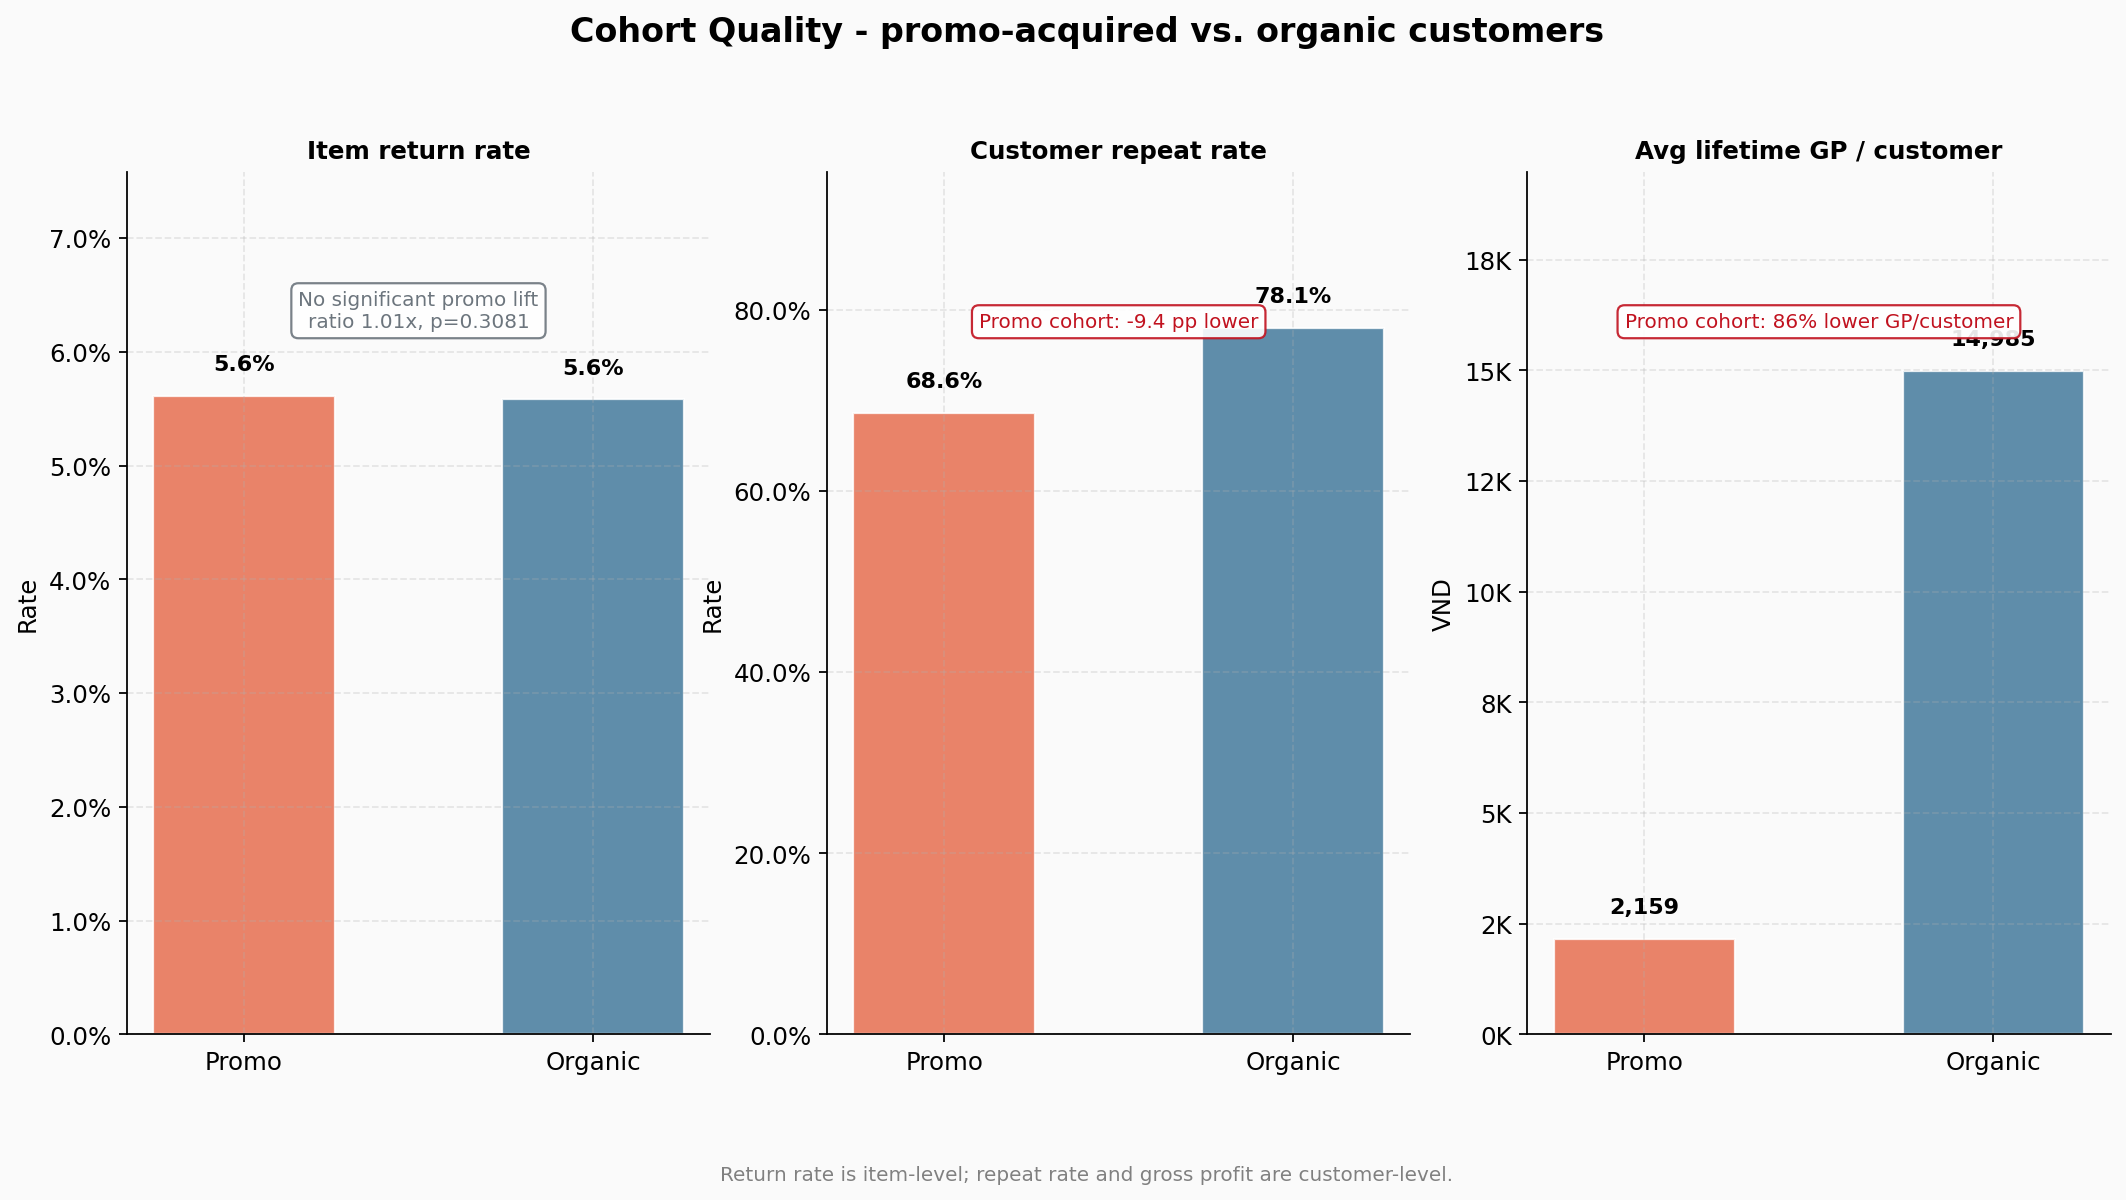

In [9]:
display(Image(str(CHARTS / "chart4_cohort_quality.png"), width=950))


In [10]:
triage = pd.read_csv(TABLES / "promo_triage_table.csv")
cohort = pd.read_csv(TABLES / "cohort_quality_table.csv")
print(f"Tỷ lệ chương trình có đóng góp lợi nhuận gộp âm: {(triage['total_net_contribution'] < 0).mean() * 100:.1f}%")
cohort_display = cohort.copy()
cohort_display["metric"] = cohort_display["metric"].replace({
    "item_return_rate": "tỷ lệ trả hàng",
    "customer_repeat_rate": "tỷ lệ mua lại",
    "avg_lifetime_gp_per_customer": "lợi nhuận gộp vòng đời mỗi khách",
})
cohort_display = cohort_display.rename(columns={
    "metric": "chỉ số",
    "promo": "nhóm khuyến mãi",
    "organic": "nhóm tự nhiên",
    "difference": "chênh lệch",
})
display(cohort_display)


Tỷ lệ chương trình có đóng góp lợi nhuận gộp âm: 100.0%


,chỉ số,nhóm khuyến mãi,nhóm tự nhiên,chênh lệch
0,tỷ lệ trả hàng,0.056157,0.055817,0.000341
1,tỷ lệ mua lại,0.686391,0.780608,-0.094217
2,lợi nhuận gộp vòng đời mỗi khách,2158.906127,14985.089993,-12826.183867


## Phân tích

Sau khi tính hoàn tiền và phí vận chuyển, **100.0% chương trình khuyến mãi có đóng góp lợi nhuận gộp âm**. Đây là kết quả rất mạnh: toàn bộ mẫu khuyến mãi lịch sử trong dữ liệu đều không qua được ngưỡng lợi nhuận gộp.

Phân tích nhóm khách hàng cho thấy **tỷ lệ trả hàng của khách đến từ khuyến mãi không cao hơn một cách có ý nghĩa thống kê**: nhóm khuyến mãi **5.62%**, nhóm tự nhiên **5.58%**, Mann-Whitney một phía **p = 0.3081**. Do đó, chưa đủ cơ sở để khẳng định khuyến mãi làm tỷ lệ trả hàng tăng đáng kể, nhưng có thể quan sát thấy khuyến mãi không làm giảm tỷ lệ trả hàng ***mà thậm chí có xu hướng làm chỉ số này tăng nhẹ***.

Luận điểm chính đến từ hai chỉ số khác:

- Tỷ lệ mua lại của khách hàng: nhóm khuyến mãi **68.6%** so với nhóm tự nhiên **78.1%**.
- Lợi nhuận gộp vòng đời trên mỗi khách hàng sau hoàn tiền và phí vận chuyển: nhóm khuyến mãi **2,159 VND** so với nhóm tự nhiên **14,985 VND**, thấp hơn **86%**.

**Kết luận Act 2:** Tác hại của khuyến mãi chủ yếu đến từ biên lợi nhuận bị nén và hiệu quả kinh tế khách hàng yếu, không phải từ hành vi trả hàng. Việc khuyến mãi như này có thể tạo ra xu hướng xấu cho khách hàng, ***chỉ khi nào có giảm giá thì mới mua, và khi mua rồi thì cũng không có động lực để quay lại***. 
### Liệu cắt khuyến mãi có bền vững dưới các kịch bản khác nhau không ?



# Act 3 - Mô phỏng kịch bản nếu cắt khuyến mãi âm

**Câu hỏi trung tâm:** Nếu cắt các chương trình có đóng góp lợi nhuận gộp âm, kết quả tài chính thay đổi thế nào dưới các giả định nhu cầu quay lại khác nhau?

Dự báo tuyến tính chỉ đóng vai trò cảnh báo rủi ro; phần quyết định chính là mô phỏng kịch bản tài chính khi cắt các chương trình âm lợi nhuận.


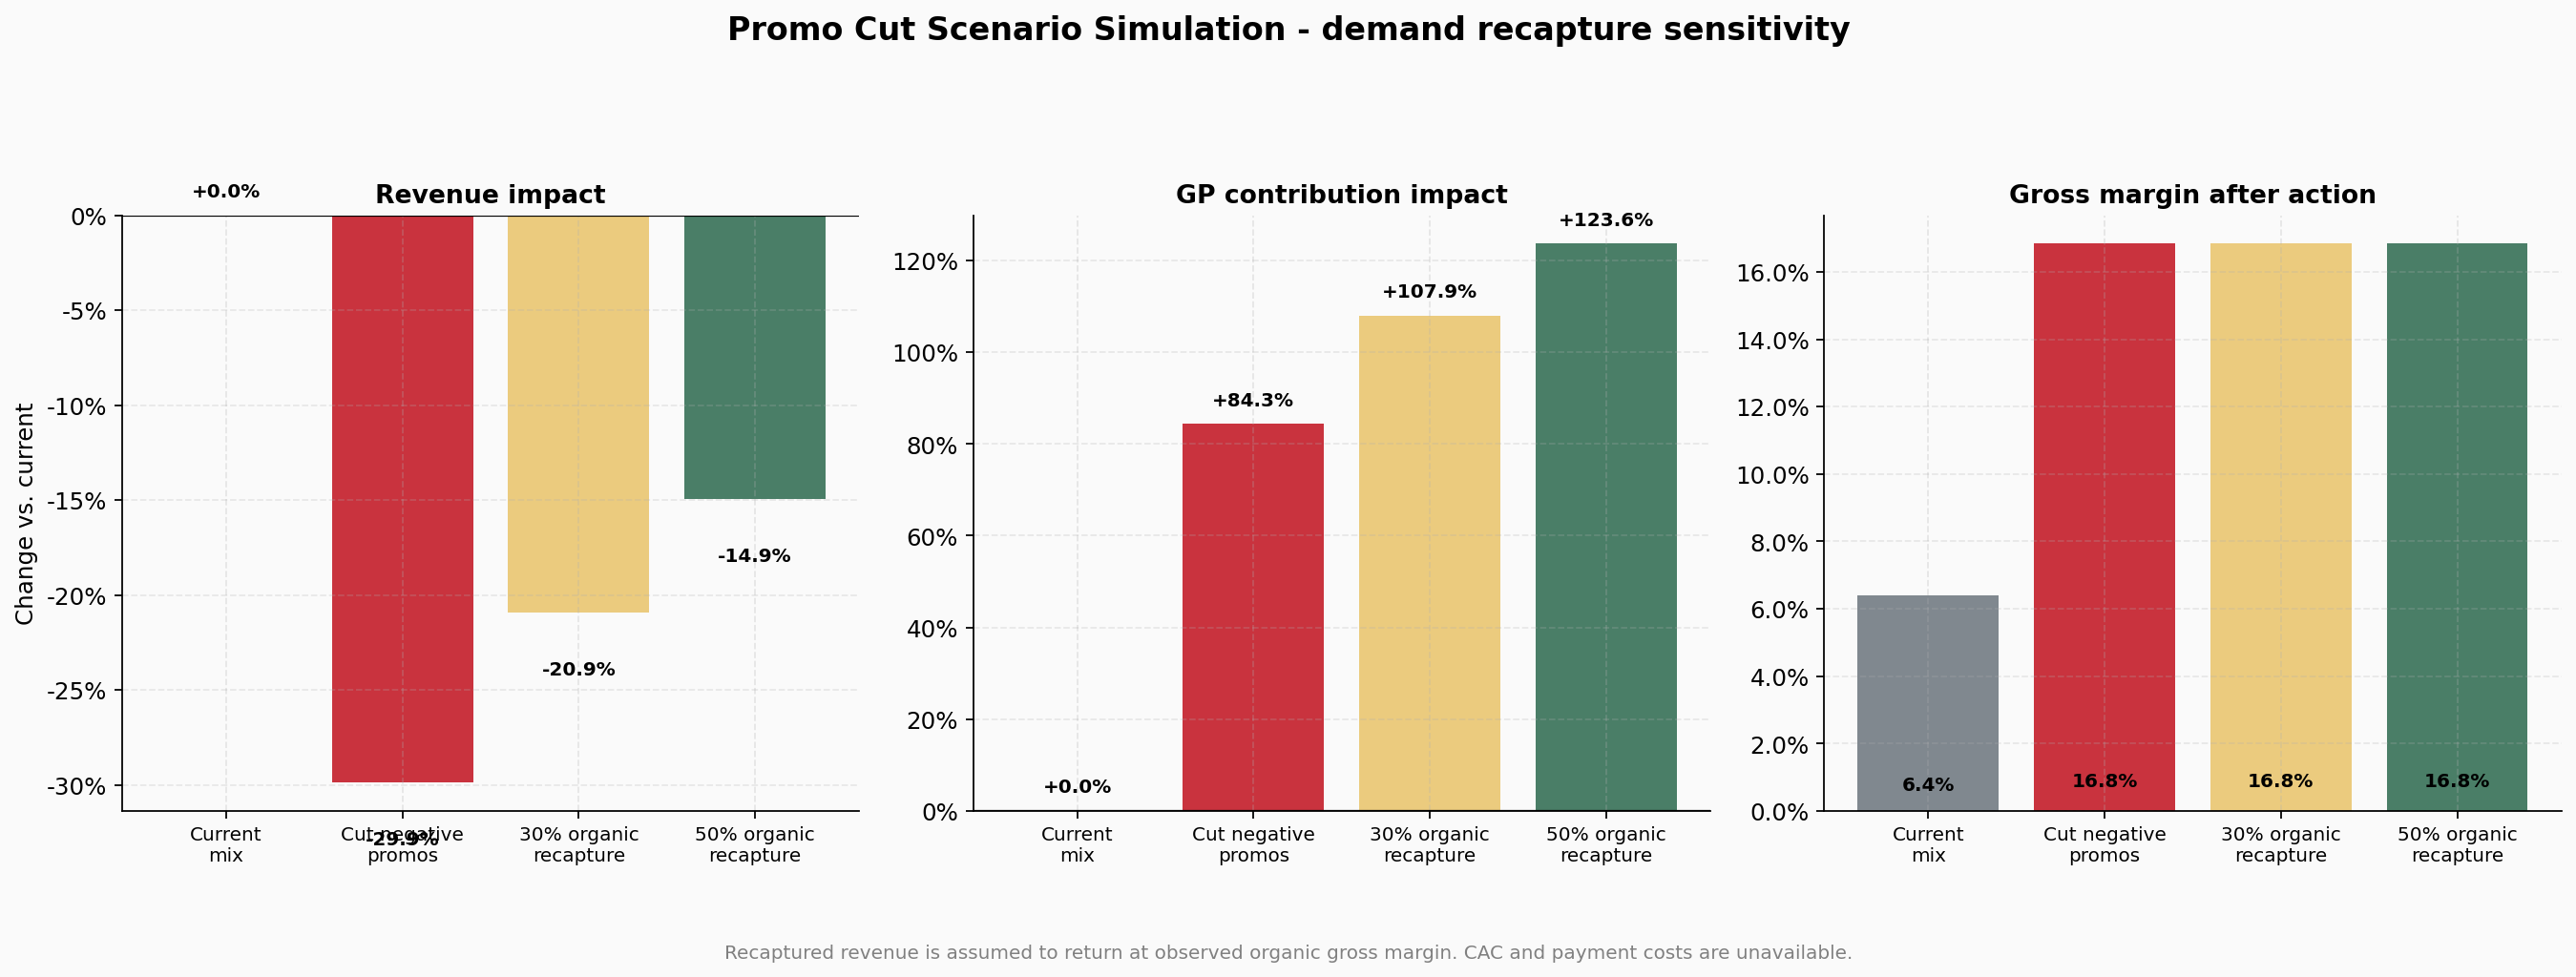

In [7]:
display(Image(str(CHARTS / "chart5_margin_scenario_simulation.png"), width=950))


In [8]:
scenario = pd.read_csv(TABLES / "promo_cut_scenario_table.csv")
scenario_display = scenario.copy()
scenario_display["assumption"] = scenario_display["assumption"].replace({
    "All promotions continue": "Giữ nguyên toàn bộ khuyến mãi",
    "0% of removed promo revenue returns at organic margin": "0% doanh thu khuyến mãi bị cắt quay lại ở biên tự nhiên",
    "30% of removed promo revenue returns at organic margin": "30% doanh thu khuyến mãi bị cắt quay lại ở biên tự nhiên",
    "50% of removed promo revenue returns at organic margin": "50% doanh thu khuyến mãi bị cắt quay lại ở biên tự nhiên",
})
scenario_display = scenario_display.rename(columns={
    "scenario": "kich_ban",
    "recapture_rate": "ty_le_nhu_cau_quay_lai",
    "revenue": "doanh_thu",
    "gp_contribution": "dong_gop_loi_nhuan_gop",
    "gross_margin": "bien_loi_nhuan_gop",
    "revenue_impact_pct": "tac_dong_doanh_thu_pct",
    "gp_impact_pct": "tac_dong_loi_nhuan_gop_pct",
    "assumption": "gia_dinh",
})
display(scenario_display)
forecast = pd.read_csv(TABLES / "margin_forecast_table.csv")
forecast_display = forecast[forecast["quarter"].isin(["2026Q4", "2027Q4"])].rename(columns={
    "quarter": "quy",
    "date": "ngay",
    "forecast": "du_bao",
    "lower_1sd": "can_duoi_1sd",
    "upper_1sd": "can_tren_1sd",
})
display(forecast_display)


,kich_ban,ty_le_nhu_cau_quay_lai,doanh_thu,dong_gop_loi_nhuan_gop,bien_loi_nhuan_gop,tac_dong_doanh_thu_pct,tac_dong_loi_nhuan_gop_pct,gia_dinh
0,Current mix,NaN,1.568087e+10,1.004011e+09,0.064028,0.000000,0.000000,Giữ nguyên toàn bộ khuyến mãi
1,Cut negative promos,0.0,1.099504e+10,1.850890e+09,0.168339,-29.882465,84.349626,0% doanh thu khuyến mãi bị cắt quay lại ở biên...
2,Cut + 30% organic recapture,0.3,1.240079e+10,2.087532e+09,0.168339,-20.917725,107.919284,30% doanh thu khuyến mãi bị cắt quay lại ở biê...
3,Cut + 50% organic recapture,0.5,1.333795e+10,2.245294e+09,0.168339,-14.941232,123.632390,50% doanh thu khuyến mãi bị cắt quay lại ở biê...


,quy,ngay,du_bao,can_duoi_1sd,can_tren_1sd
15,2026Q4,2026-10-01,-0.129175,-8.979894,8.721543
19,2027Q4,2027-10-01,-0.691601,-9.542319,8.159118


## Phân tích

Hiện trạng tạo **15,680,869,265 VND doanh thu**, **1,004,010,930 VND đóng góp lợi nhuận gộp sau hoàn tiền và phí vận chuyển**, tương ứng biên lợi nhuận gộp **6.4%**.

Trong kịch bản thận trọng nhất **0% nhu cầu quay lại**, cắt **50 chương trình âm lợi nhuận gộp** làm doanh thu giảm còn **10,995,039,053 VND** (**-29.9%**), nhưng đóng góp lợi nhuận gộp tăng lên **1,850,890,392 VND** (**+84.3%**) và biên lợi nhuận gộp tăng lên **16.8%**.

Nếu **30% doanh thu khuyến mãi bị mất quay lại ở biên lợi nhuận tự nhiên**, doanh thu còn **12,400,788,117 VND** (**-20.9%**) và đóng góp lợi nhuận gộp tăng **+107.9%**. Với **50% nhu cầu quay lại**, doanh thu còn **13,337,954,159 VND** (**-14.9%**) và đóng góp lợi nhuận gộp tăng **+123.6%**.

Dự báo tuyến tính chỉ là cảnh báo rủi ro, không phải quy tắc ra quyết định. Xu hướng gần đây giảm khoảng **0.1 điểm %/quý**, biên lợi nhuận bốn quý gần nhất chỉ **4.4%**. Dự báo **Q4/2026 là -0.1%** với khoảng dao động **-9.0% đến 8.7%**; **Q4/2027 là -0.7%** với khoảng dao động **-9.5% đến 8.2%**. Khoảng dao động quá rộng nên không đủ để ra quyết định một mình.

**Kết luận Act 3:** Mô phỏng kịch bản là bằng chứng dự báo chính: cắt khuyến mãi âm vẫn cải thiện lợi nhuận gộp ngay cả khi không có nhu cầu quay lại.


# Act 4 - Khuyến mãi chạy vào vùng rủi ro tồn kho

**Câu hỏi trung tâm:** Khuyến mãi có đang được kích hoạt trong giai đoạn ngành hàng có mức sẵn sàng tồn kho yếu không?

Phân tích tập trung vào giao điểm giữa lịch khuyến mãi và tồn kho yếu ở cấp chương trình x ngành hàng x tháng.


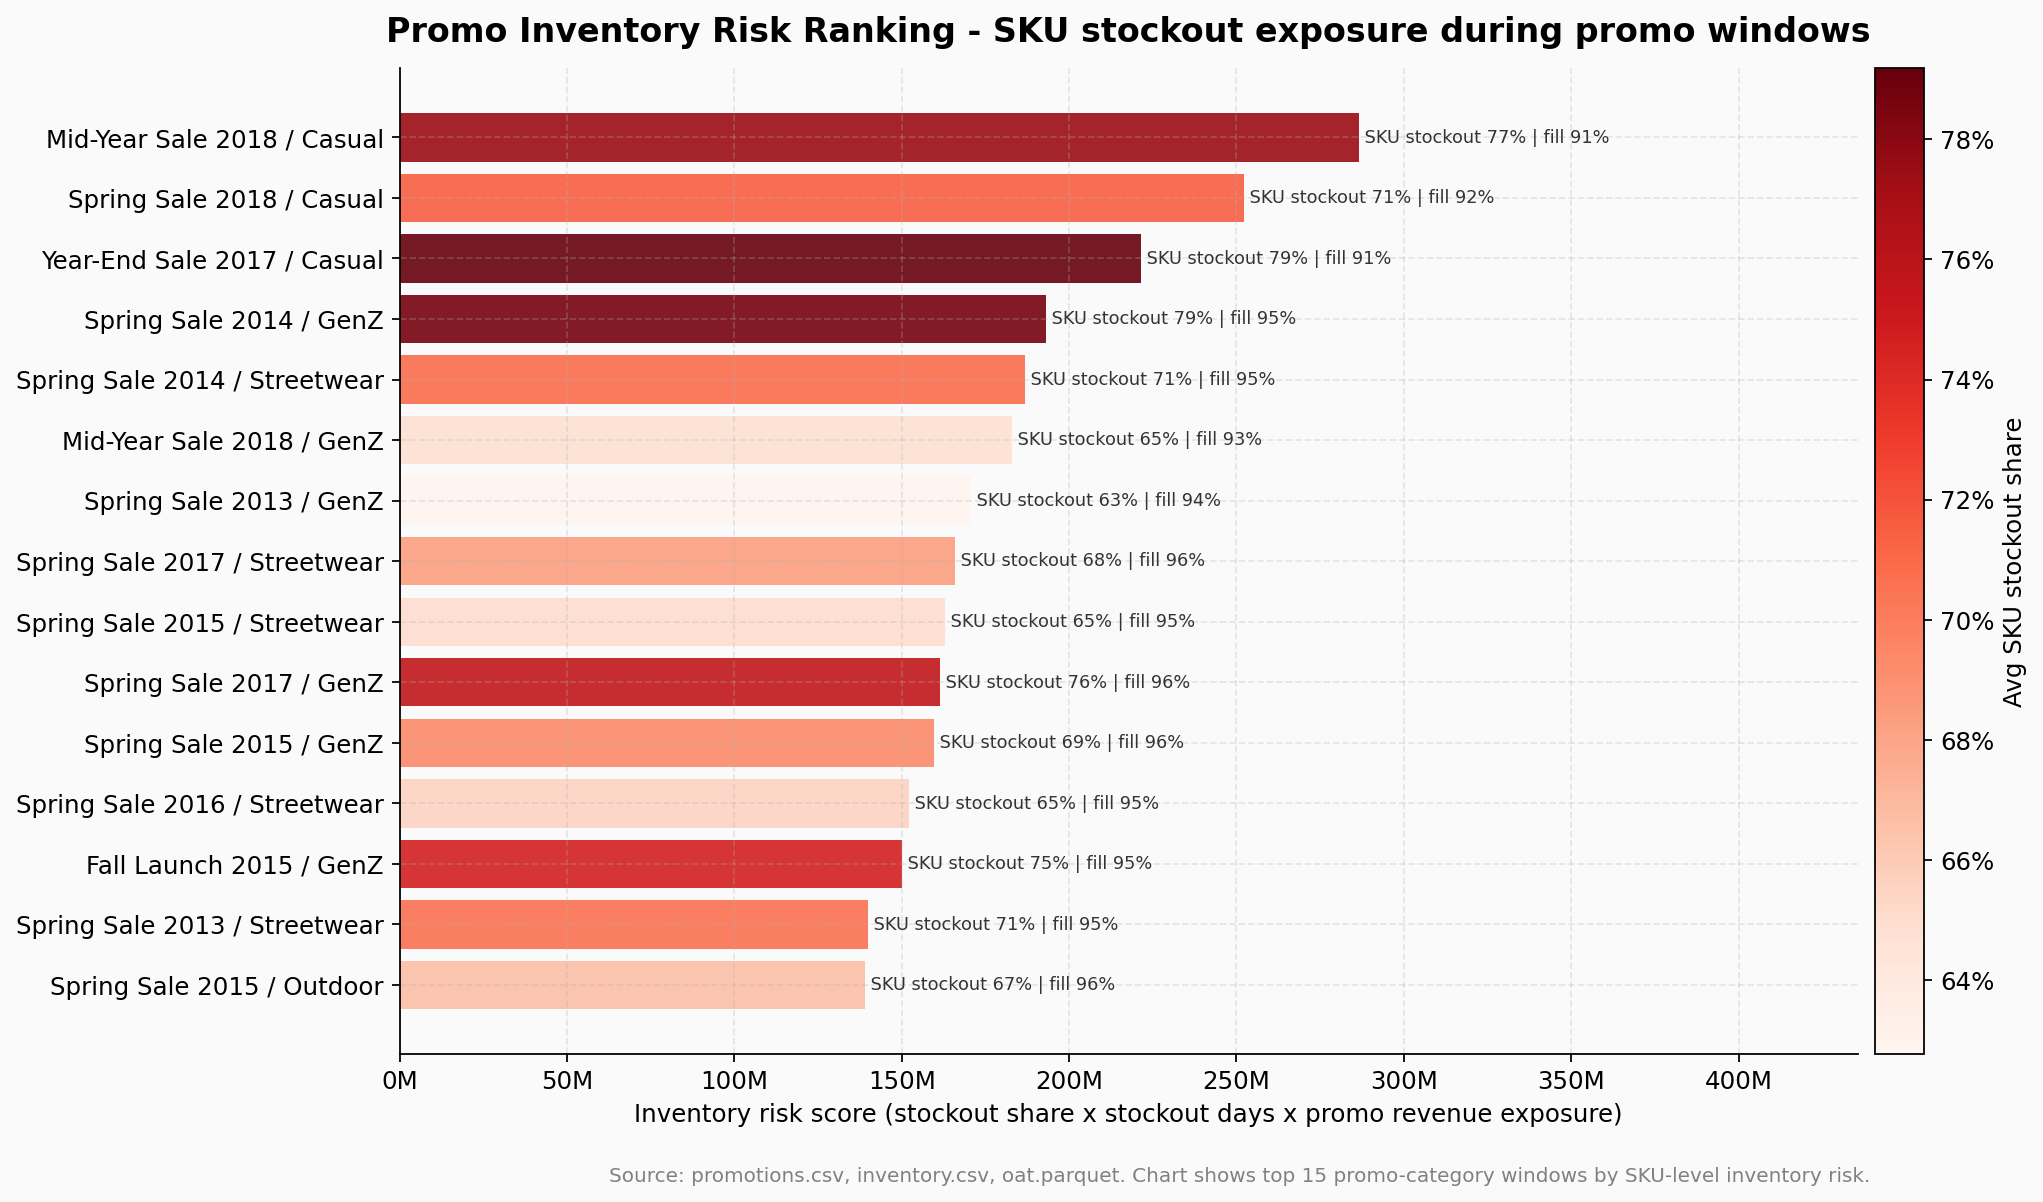

In [9]:
display(Image(str(CHARTS / "chart6_promo_inventory_risk.png"), width=950))


In [10]:
overlaps = pd.read_csv(TABLES / "promo_stockout_overlaps.csv")
risk = pd.read_csv(TABLES / "promo_inventory_risk_table.csv")
print(f"Số event chồng lấn: {len(overlaps)}")
print(f"Số chương trình bị ảnh hưởng: {overlaps['promo_id'].nunique()}")
print(f"Ngành hàng bị ảnh hưởng: {sorted(overlaps['category'].unique().tolist())}")
print(f"Tỷ lệ SKU thiếu hàng trung bình: {overlaps['stockout_product_share'].mean():.1%}")
print(f"Tỷ lệ đáp ứng đơn trung bình: {overlaps['avg_fill_rate'].mean():.1%}")
print(f"Lợi nhuận gộp ước tính bị mất: {overlaps['estimated_lost_gp'].sum():,.0f} VND")
risk_display = risk.head(20).rename(columns={
    "promo_id": "ma_khuyen_mai",
    "promo_name": "ten_khuyen_mai",
    "category": "nganh_hang",
    "overlap_months": "so_thang_chong_lan",
    "avg_sku_stockout_share": "ty_le_sku_thieu_hang_tb",
    "avg_fill_rate": "ty_le_dap_ung_don_tb",
    "estimated_lost_gp": "loi_nhuan_gop_uoc_tinh_mat",
    "promo_gp_contribution": "dong_gop_loi_nhuan_gop",
    "promo_net_revenue": "doanh_thu_thuan_khuyen_mai",
    "inventory_risk_score": "diem_rui_ro_ton_kho",
})
display(risk_display)


Số event chồng lấn: 426
Số chương trình bị ảnh hưởng: 50
Ngành hàng bị ảnh hưởng: ['Casual', 'GenZ', 'Outdoor', 'Streetwear']
Tỷ lệ SKU thiếu hàng trung bình: 67.5%
Tỷ lệ đáp ứng đơn trung bình: 96.2%
Lợi nhuận gộp ước tính bị mất: 23,547,465 VND


,ma_khuyen_mai,ten_khuyen_mai,nganh_hang,so_thang_chong_lan,ty_le_sku_thieu_hang_tb,max_sku_stockout_share,avg_stockout_days,max_stockout_days,ty_le_dap_ung_don_tb,min_fill_rate,loi_nhuan_gop_uoc_tinh_mat,dong_gop_loi_nhuan_gop,doanh_thu_thuan_khuyen_mai,negative_gp_exposure,diem_rui_ro_ton_kho
0,PROMO-0028,Mid-Year Sale 2018,Casual,2,0.774194,0.870968,2.629032,22,0.912366,0.2667,7.932671e+04,-3.028329e+07,1.407959e+08,3.028329e+07,2.865731e+08
1,PROMO-0027,Spring Sale 2018,Casual,2,0.714683,0.774194,2.369855,18,0.921008,0.4000,2.473240e+04,-8.596910e+06,1.489566e+08,8.596910e+06,2.522871e+08
2,PROMO-0024,Year-End Sale 2017,Casual,3,0.791795,0.846154,2.805128,19,0.906494,0.3667,3.386859e+04,-2.743982e+07,9.974252e+07,2.743982e+07,2.215367e+08
3,PROMO-0007,Spring Sale 2014,GenZ,2,0.786718,0.814815,1.508940,10,0.949701,0.6667,1.159950e+04,-1.246593e+07,1.626504e+08,1.246593e+07,1.930839e+08
4,PROMO-0007,Spring Sale 2014,Streetwear,2,0.708615,0.731183,1.620530,28,0.945981,0.0667,5.748829e+05,-1.246593e+07,1.626504e+08,1.246593e+07,1.867765e+08
5,PROMO-0028,Mid-Year Sale 2018,GenZ,2,0.647969,0.659574,2.003868,17,0.933203,0.4333,1.000183e+05,-3.028329e+07,1.407959e+08,3.028329e+07,1.828157e+08
6,PROMO-0001,Spring Sale 2013,GenZ,2,0.627706,0.636364,1.906926,23,0.936437,0.2333,1.284082e+04,-8.785409e+06,1.426156e+08,8.785409e+06,1.707092e+08
7,PROMO-0021,Spring Sale 2017,Streetwear,2,0.683382,0.728302,1.349492,22,0.955017,0.2667,4.351671e+05,-1.211826e+07,1.797860e+08,1.211826e+07,1.658019e+08
8,PROMO-0011,Spring Sale 2015,Streetwear,2,0.650025,0.699275,1.421343,25,0.952622,0.1667,5.584992e+05,-1.035161e+07,1.762220e+08,1.035161e+07,1.628130e+08
9,PROMO-0021,Spring Sale 2017,GenZ,2,0.756536,0.777778,1.186275,2,0.960454,0.9333,4.740742e+03,-1.211826e+07,1.797860e+08,1.211826e+07,1.613507e+08


## Phân tích

Sau khi xử lý data, có **426 điểm chồng lấn** ở cấp **chương trình x ngành hàng x tháng**, trải trên **50 chương trình** và 4 ngành hàng: **Casual, GenZ, Outdoor, Streetwear**.

Tỷ lệ đáp ứng đơn trung bình trong các tháng chồng lấn là **96.2%**, nên đây không phải thất bại tồn kho toàn ngành hàng. Điểm rủi ro nằm ở cấp SKU: trung bình **67.5% SKU trong ngành hàng có `stockout_flag = 1`** trong các tháng khuyến mãi chồng lấn.

Bảng xếp hạng rủi ro cho thấy cặp chương trình-ngành hàng rủi ro cao nhất là **Mid-Year Sale 2018 / Casual**, với điểm rủi ro **286,573,111**. Lợi nhuận gộp ước tính bị mất từ các điểm chồng lấn là **23,547,465 VND**.

**Kết luận Act 4:** Cần cổng kiểm tra tồn kho trước khi chạy khuyến mãi. Cổng này nên kiểm tra tỷ lệ SKU thiếu hàng và mức sẵn sàng của ngành hàng, không chỉ nhìn tỷ lệ đáp ứng đơn tổng hợp.


# Act 5 - Kê đơn hành động cho từng chương trình

**Câu hỏi trung tâm:** Dựa trên hiệu quả tài chính, chất lượng khách hàng và rủi ro tồn kho, chương trình nào nên KEEP, CUT hoặc RESCHEDULE?

Phần cuối chuyển toàn bộ kết quả phân tích thành quyết định cụ thể cho từng chương trình.


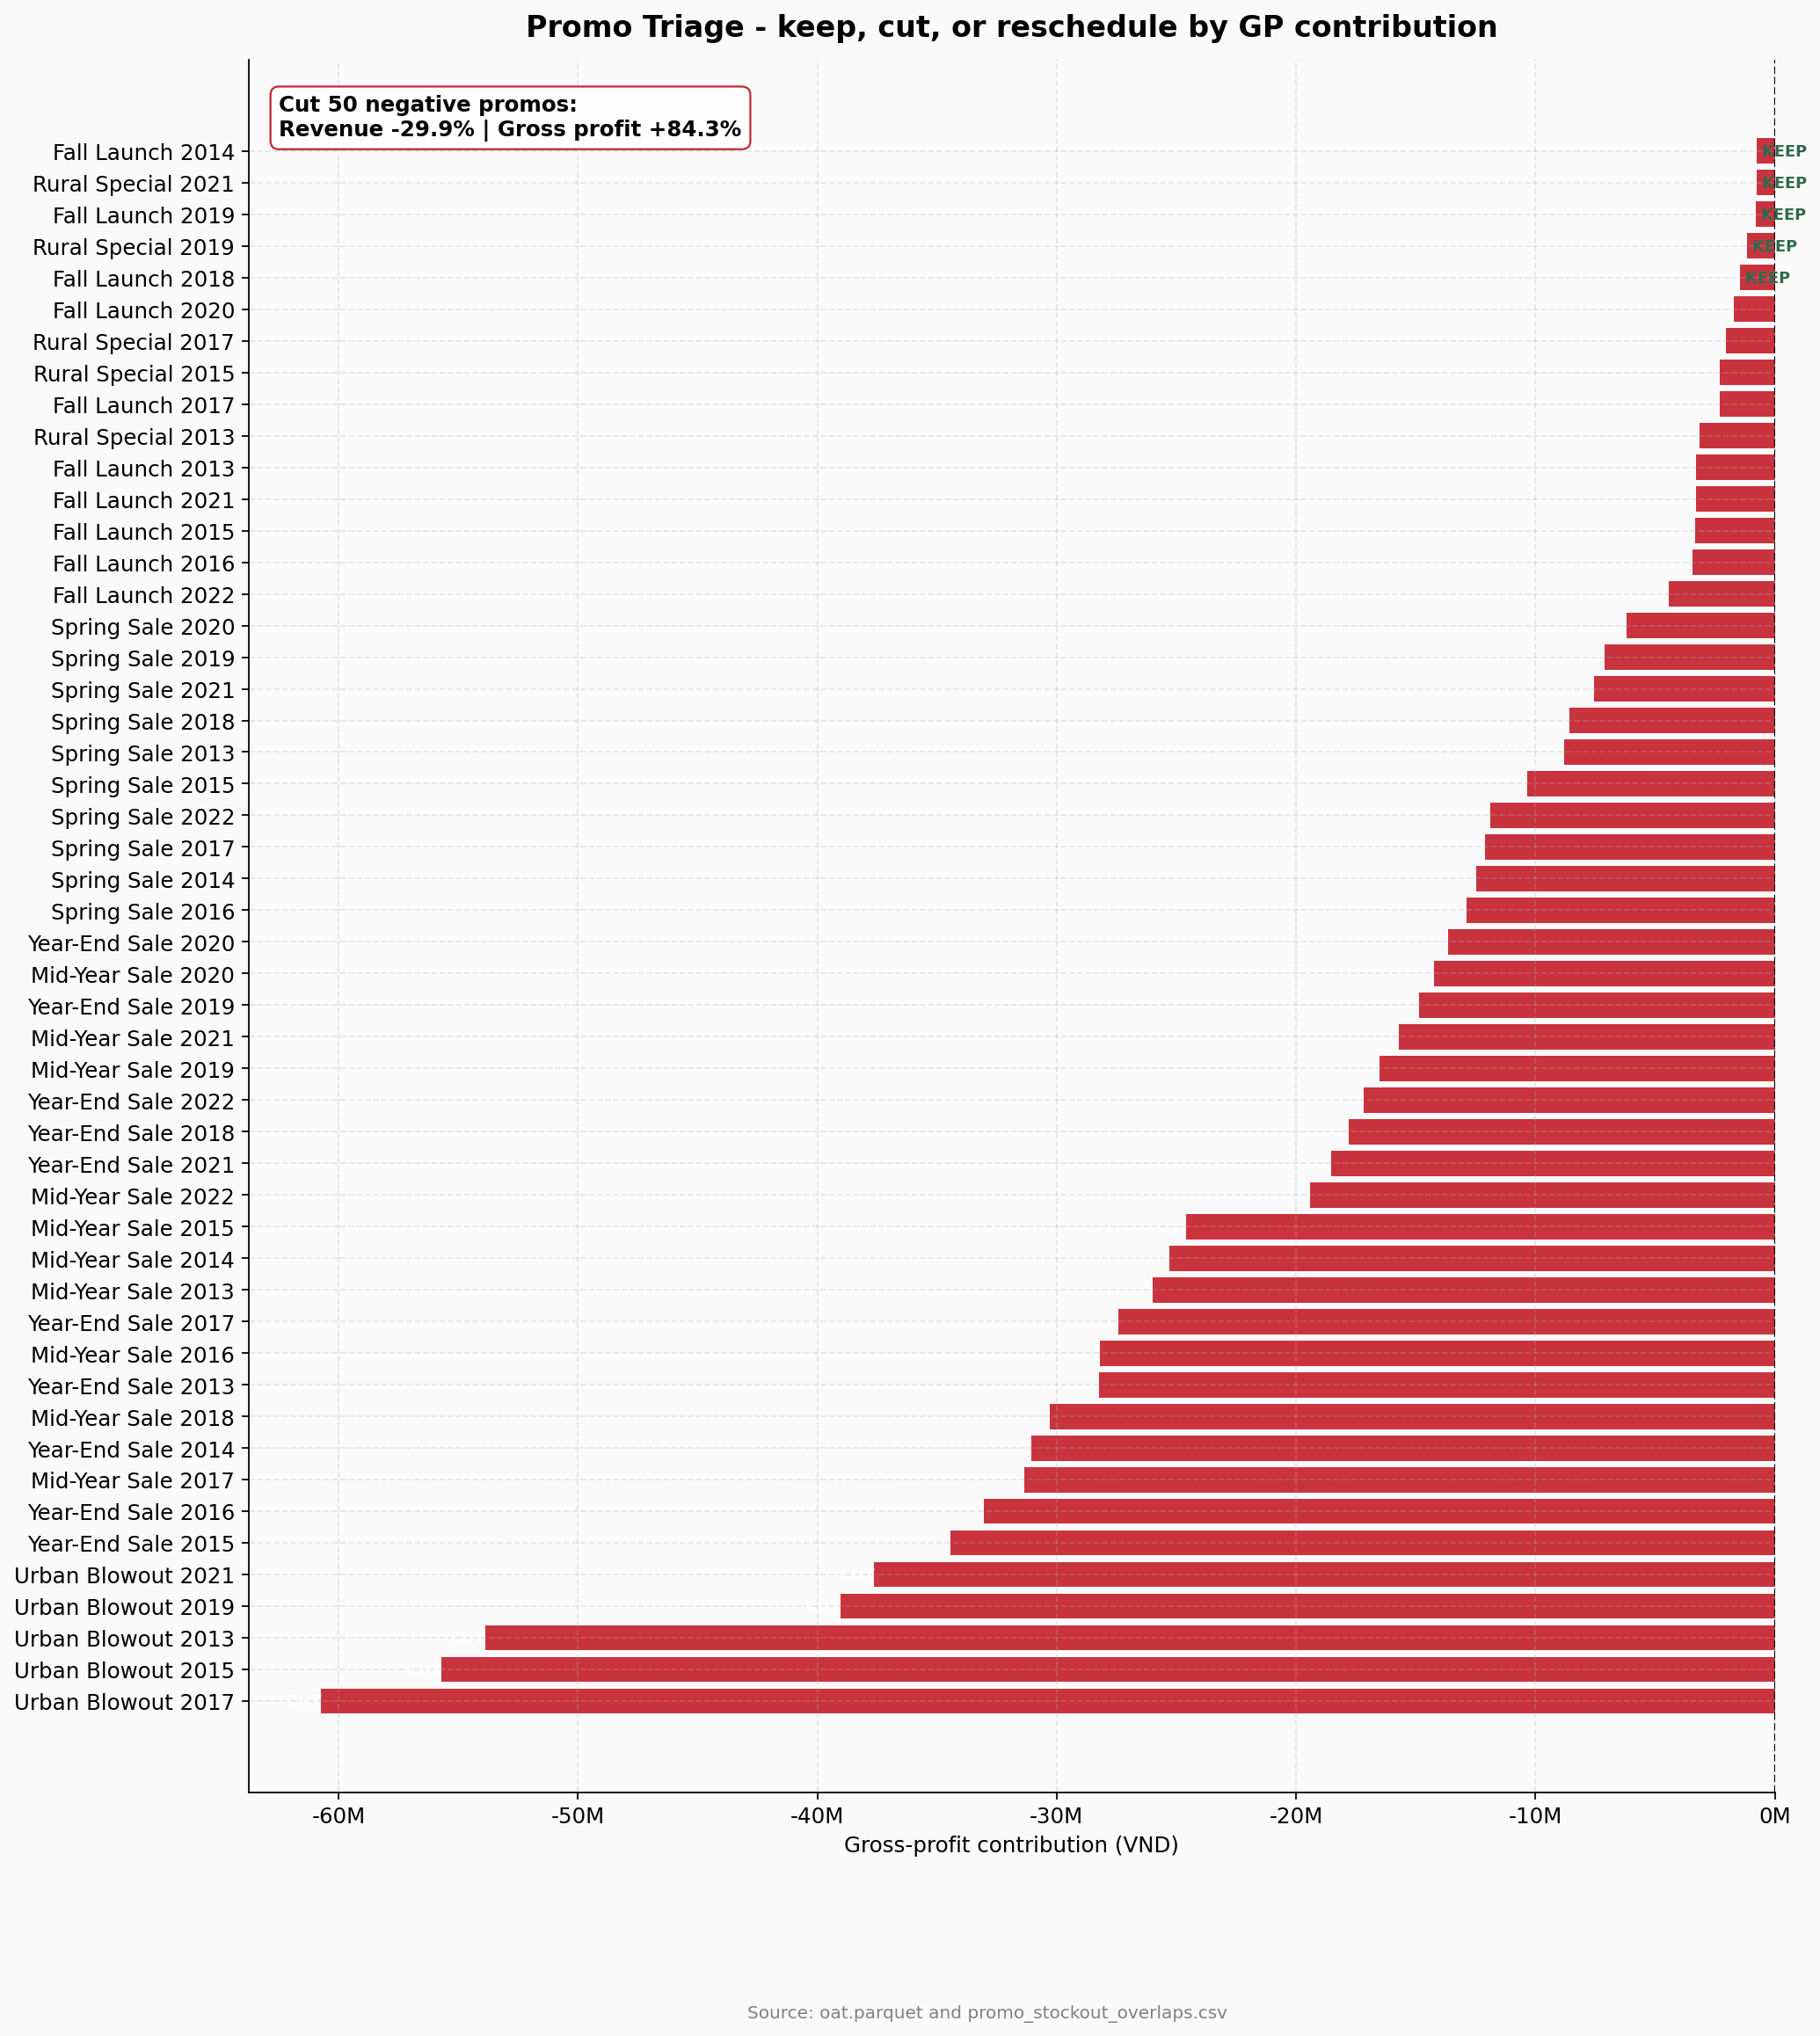

In [11]:
display(Image(str(CHARTS / "chart7_promo_triage.png"), width=950))


In [12]:
triage = pd.read_csv(TABLES / "promo_triage_table.csv")
summary = triage.groupby("verdict").agg(
    count=("promo_id", "count"),
    total_net_contribution=("total_net_contribution", "sum"),
    estimated_annual_impact_vnd=("estimated_annual_impact_vnd", "sum"),
).reset_index()
summary_display = summary.rename(columns={
    "verdict": "quyet_dinh",
    "count": "so_chuong_trinh",
    "total_net_contribution": "tong_dong_gop_loi_nhuan_gop",
    "estimated_annual_impact_vnd": "tac_dong_uoc_tinh_nam_vnd",
})
display(summary_display)
print("Các chương trình CUT ít âm nhất")
cols = ["promo_name", "total_net_contribution", "return_rate", "stockout_overlap"]
display(triage[triage.verdict == "CUT"].nlargest(5, "total_net_contribution")[cols].rename(columns={
    "promo_name": "ten_khuyen_mai",
    "total_net_contribution": "dong_gop_loi_nhuan_gop",
    "return_rate": "ty_le_tra_hang",
    "stockout_overlap": "chong_lan_thieu_hang",
}))
print("Các chương trình CUT âm nặng nhất")
display(triage[triage.verdict == "CUT"].nsmallest(5, "total_net_contribution")[cols].rename(columns={
    "promo_name": "ten_khuyen_mai",
    "total_net_contribution": "dong_gop_loi_nhuan_gop",
    "return_rate": "ty_le_tra_hang",
    "stockout_overlap": "chong_lan_thieu_hang",
}))


,quyet_dinh,so_chuong_trinh,tong_dong_gop_loi_nhuan_gop,tac_dong_uoc_tinh_nam_vnd
0,CUT,50,-8.468795e+08,8.468795e+08


Các chương trình CUT ít âm nhất


,ten_khuyen_mai,dong_gop_loi_nhuan_gop,ty_le_tra_hang,chong_lan_thieu_hang
0,Fall Launch 2014,-7.769355e+05,0.056413,Yes
1,Rural Special 2021,-7.771840e+05,0.064626,Yes
2,Fall Launch 2019,-7.811778e+05,0.059013,Yes
3,Rural Special 2019,-1.151314e+06,0.054529,Yes
4,Fall Launch 2018,-1.454776e+06,0.055915,Yes


Các chương trình CUT âm nặng nhất


,ten_khuyen_mai,dong_gop_loi_nhuan_gop,ty_le_tra_hang,chong_lan_thieu_hang
49,Urban Blowout 2017,-6.072388e+07,0.058682,Yes
48,Urban Blowout 2015,-5.570163e+07,0.056979,Yes
47,Urban Blowout 2013,-5.386512e+07,0.052589,Yes
46,Urban Blowout 2019,-3.903958e+07,0.055451,Yes
45,Urban Blowout 2021,-3.762514e+07,0.057155,Yes


## Phân tích

Triage cho kết quả:

- **KEEP: 0 chương trình**.
- **CUT: 50 chương trình**, tổng đóng góp lợi nhuận gộp **-846,879,462 VND**.
- **RESCHEDULE: 0 chương trình**.

Đây là kết quả rất nặng: sau khi tính hoàn tiền và phí vận chuyển, không có chương trình khuyến mãi lịch sử nào còn đóng góp lợi nhuận gộp dương. Vì vậy khuyến nghị không phải "giữ một vài khuyến mãi tốt", mà là **dừng lặp lại toàn bộ mẫu khuyến mãi lịch sử cho tới khi thiết kế lại cơ chế khuyến mãi**.

Đánh đổi trong kịch bản thận trọng nhất: cắt các chương trình âm làm doanh thu giảm **-29.9%**, nhưng đóng góp lợi nhuận gộp tăng **+84.3%**. Với 30% nhu cầu quay lại tự nhiên, tác động doanh thu cải thiện còn **-20.9%** và đóng góp lợi nhuận gộp tăng **+107.9%**.

**Kết luận Act 5:** Loại toàn bộ 50 mẫu khuyến mãi lịch sử khỏi sổ tay vận hành hiện tại. Khuyến mãi mới chỉ nên triển khai nếu đóng góp lợi nhuận gộp dự kiến sau hoàn tiền và phí vận chuyển dương, hiệu quả kinh tế khách hàng không thấp hơn nhóm tự nhiên, và cổng kiểm tra tồn kho đạt yêu cầu.


---
## Tóm tắt điều hành

1. Chất lượng doanh thu đang xấu đi: **749,607,320 VND** rò rỉ qua chiết khấu, **510,598,507 VND** rò rỉ qua hoàn tiền, và biên lợi nhuận sau hoàn tiền + phí vận chuyển giảm từ **17.6%** xuống **5.4%**.

2. Khuyến mãi là vấn đề kinh tế chính: **100.0% chương trình có đóng góp lợi nhuận gộp âm**. Tỷ lệ trả hàng không khác biệt có ý nghĩa thống kê, nhưng khách hàng từ khuyến mãi có tỷ lệ mua lại thấp hơn và tạo **ít hơn 86% lợi nhuận gộp vòng đời trên mỗi khách hàng**.

3. Mô phỏng kịch bản cho thấy quyết định cắt vẫn bền: kịch bản thận trọng nhất **doanh thu -29.9% / đóng góp lợi nhuận gộp +84.3%**; với 30% nhu cầu quay lại tự nhiên, tác động doanh thu là **-20.9%** và đóng góp lợi nhuận gộp tăng **+107.9%**.

4. Chồng lấn giữa khuyến mãi và thiếu hàng tồn tại ở cấp SKU/ngành hàng: **426 điểm chồng lấn**, **67.5% tỷ lệ SKU thiếu hàng trung bình**, **96.2% tỷ lệ đáp ứng đơn trung bình**. Rủi ro cao nhất là **Mid-Year Sale 2018 / Casual**.

5. Kê đơn hành động: **KEEP 0**, **CUT 50**, **RESCHEDULE 0**. Không nên lặp lại các mẫu khuyến mãi lịch sử; cần thiết kế lại cơ chế khuyến mãi.

## Ba khuyến nghị hành động

| Ưu tiên | Hành động | Tác động ước tính |
|---|---|---|
| 1 | Dừng 50 mẫu khuyến mãi lịch sử đang âm lợi nhuận gộp | Đóng góp lợi nhuận gộp +84.3% trong kịch bản thận trọng nhất |
| 2 | Thiết kế lại cổng duyệt khuyến mãi theo lợi nhuận gộp dự kiến sau hoàn tiền | Không triển khai nếu đóng góp lợi nhuận gộp dự kiến <= 0 |
| 3 | Thêm cổng kiểm tra tồn kho trước khi triển khai khuyến mãi | Chặn khuyến mãi khi mức thiếu hàng SKU quá cao |

## Giới hạn bằng chứng

- Đây là phép lọc theo đóng góp lợi nhuận gộp sau hoàn tiền và phí vận chuyển, chưa phải biên đóng góp đầy đủ vì dữ liệu không có chi phí thu hút khách hàng, chi phí xử lý thanh toán và chi phí vận hành cố định.
- Tác động doanh thu **-29.9%** là kịch bản cơ học thận trọng nhất, giả định không có nhu cầu quay lại.
- Dự báo tuyến tính có độ bất định rộng; mô phỏng kịch bản là kiểm định quyết định chính.
- Dữ liệu đánh giá không xác nhận mức hài lòng khách hàng giảm sau các điểm chồng lấn với thiếu hàng.
